# Calling Cellpose from skop

There are two Cellpose ops, because there are two Cellposes. Cellpose 4
replaced the old model zoo with a single CPSAM model and changed the API slightly, so 
one environment can no longer hold both:

| op | runs | models |
| --- | --- | --- |
| `cellpose` | Cellpose 4 | CPSAM, and CPSAM models you trained |
| `cellpose3` | Cellpose 3 | cyto3, nuclei, ... and CPnet models you trained |

This notebook calls them in the four situations  --
a built-in, and a user fine-tuned model for each -- first with the shortest
call that works, then with the settings that actually got good results on this
image. Every call is written out in full, so you can copy the one that matches
your case.

## Setup

This notebook needs almost nothing installed: a kernel, matplotlib, tifffile,
scikit-image. Cellpose is *not* installed here. Each op runs in an environment
skop builds for it the first time you call it, which is why two versions of
Cellpose can both work from one notebook.

### PIP

If you have an environment and install the below dependencies, you should be able to run this notebook (in fact you should be able to just copy and past the code from each cell, without even cloning the code).

```
pip install ipykernel matplotlib tifffile scikit-image \
    "scikit-ops @ git+https://github.com/apposed/scikit-ops.git"
```

### Pixi

If you get the repo you can install the examples pixi environment

```sh
cd pixi/examples && pixi run register-kernel    # pixi
```

On Windows, start VS Code **from inside `pixi shell`** rather than switching to
the kernel in an already-running editor. `kernel.json` launches the interpreter
without activating its environment, and matplotlib then crashes the kernel on
the first draw -- no traceback, just "Kernel crashed".

### UV

```
uv sync                                         # uv
```

The image and models live under `test_images/` which lives two directories up from this notebook in the repo.  However the test image folder is gitignored.  You can get the image from this [dropbox folder](https://www.dropbox.com/scl/fo/6tmw90z3g6spzkznn897h/AEI8jCt1dUtjTXhNerM5P3A?rlkey=4i2twwhfaaaj1xj4hp6rk73yj&st=yzeedova&dl=0).   If you put the image in a different relative location, remember to change the ```DATA``` location in the below cell. 

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import tifffile
from skimage.color import label2rgb

import skop
from skop.models import cellpose_flavor
from skop.ops.segment import cellpose, cellpose3
from skop.ops.segment.cellpose3 import (
    CytoplasmChannel,
    NucleusChannel,
    PretrainedModel,
)

# Figures are saved into this notebook as base64 PNGs, so their resolution is
# permanent repo weight. 72 dpi is plenty for looking at masks and roughly
# halves the file.
plt.rcParams["figure.dpi"] = 72

# .resolve() matters: the model path is handed to a separate worker process,
# whose working directory is not this notebook's. A relative path would not
# be found there.
DATA = Path("../../test_images/segmentation/tough_cellpose").resolve()

CP3_CUSTOM = DATA / "models" / "cellpose_for_protrusions"
CPSAM_CUSTOM = DATA / "models" / "cpsam_protrusions"

## The image

One frame of cells with long thin protrusions -- the hard case, and what both
custom models were trained on. It is RGB: the cells are **green**, the nuclei
are **blue**, and red is empty. Remember that, because it comes back later.

(750, 756, 3) uint16, range 0-65535


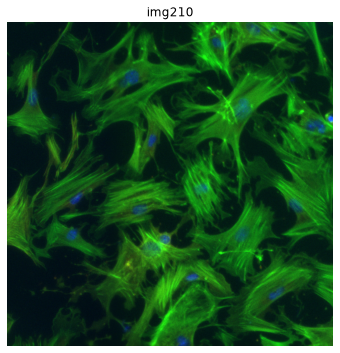

In [2]:
image = tifffile.imread(DATA / "img210.tif")

print(f"{image.shape} {image.dtype}, range {image.min()}-{image.max()}")

# A grey version, used later as the backdrop the masks are drawn on.
gray = image.mean(axis=-1)
gray = gray / gray.max()

fig, ax = plt.subplots(figsize=(5, 5))
# uint16 RGB: matplotlib wants 0-1 floats for a colour image, not raw counts.
ax.imshow(image / image.max())
ax.set_title("img210")
ax.axis("off")
fig.tight_layout()

## Which Cellpose is a model file for?

A model you trained is a file with whatever name you gave it. It does not say
which Cellpose made it, and giving it to the wrong op fails deep inside torch.

`cellpose_flavor` tells you, from the file itself -- it reads the list of layer
names out of the checkpoint without loading the weights, so it is instant even
for the 600 MB one. Give it a built-in's name instead and it just looks that up.

- `sam` means use the **`cellpose`** op.
- `cpnet` means use the **`cellpose3`** op.

In [3]:
print("cyto3            ", cellpose_flavor("cyto3"))
print("my cp3 model     ", cellpose_flavor(CP3_CUSTOM))
print("cpsam            ", cellpose_flavor("cpsam"))
print("my cpsam model   ", cellpose_flavor(CPSAM_CUSTOM))

cyto3             CellposeFlavor.cpnet
my cp3 model      CellposeFlavor.cpnet
cpsam             CellposeFlavor.sam
my cpsam model    CellposeFlavor.sam


## The runner

A Runner is a session and one of it's jobs is to create the environments.

Neither Cellpose is installed in this notebook. Each op declares the environment it needs, and the runner builds that environment the first time you call the op:

| op          | environment |
| ----------- | ----------- |
| `cellpose`  | `pytorch`   |
| `cellpose3` | `cellpose3` |

They are separate because Cellpose 3 and 4 cannot coexist in one environment 

Where do they go?  Appose keeps them in one shared place:

~/.local/share/appose/skop-<environment>

which on Windows is C:\Users\<you>\.local\share\appose\. So the two above land in skop-pytorch and skop-cellpose3. Set APPOSE_ENVS_DIR if you want them elsewhere.

First time is slow. After that it is faster. A build is minutes and gigabytes — PyTorch, CUDA, the lot. But it is cached, and the cache is keyed by environment, not by notebook. So the second call is fast, and so is the first call tomorrow, in a different notebook, or from napari — anything on this machine that asks for the same environment reuses the one already built.

The subscribe_build_progress line below prints what a build is doing. Without it, a first run is several minutes of silence that is hard to tell from a hung kernel.

In [4]:
runner = skop.Runner()

_last_message = None


def on_build(title, current, maximum):
    """Print each build step once, instead of on every tick of it."""
    global _last_message
    if title != _last_message:
        _last_message = title
        print("  [build]", title)


runner.subscribe_build_progress(on_build)

# Part 1: the shortest call that works

Every parameter has a default, so the only things you must supply are the image
and which model you want. Here are all four situations, one line each.

Note the two different ways to name a model:

- **`model=`** picks one of Cellpose 3's built-ins, from the `PretrainedModel`
  list. Type `PretrainedModel.` and press tab to see them all.
- **`pretrained_model=`** is a path to a model you trained.

and that `cellpose` needs neither when you want plain CPSAM -- that is what it
loads if you say nothing.

In [5]:
labels_cyto3 = runner.run(cellpose3, image=image, model=PretrainedModel.cyto3)
print("cyto3            ", labels_cyto3.max(), "objects")

labels_cp3_custom = runner.run(cellpose3, image=image, pretrained_model=CP3_CUSTOM)
print("my cp3 model     ", labels_cp3_custom.max(), "objects")

labels_cpsam = runner.run(cellpose, image=image)
print("cpsam            ", labels_cpsam.max(), "objects")

labels_cpsam_custom = runner.run(cellpose, image=image, pretrained_model=CPSAM_CUSTOM)
print("my cpsam model   ", labels_cpsam_custom.max(), "objects")

cyto3             105 objects
my cp3 model      11 objects
cpsam             40 objects
my cpsam model    21 objects


### What the defaults give you

Look at the protrusions. The defaults tend to clip them back to the cell body,
which is the problem Part 2 fixes.

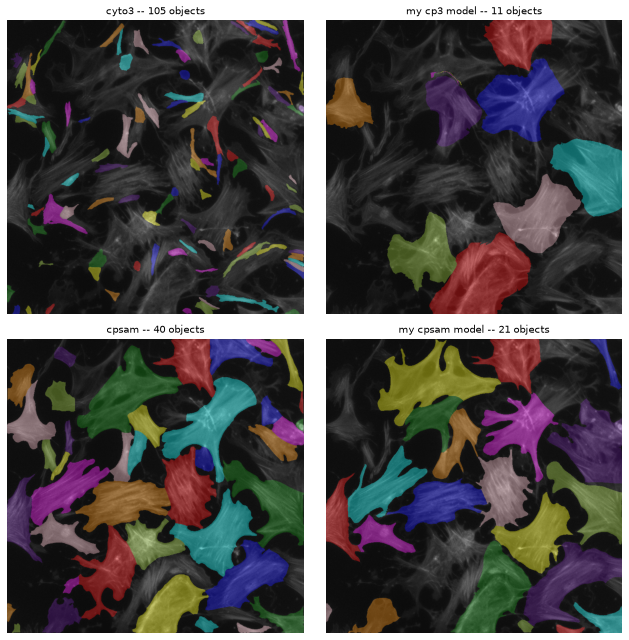

In [6]:
def show(ax, labels, title):
    """Draw a label image over the grey original."""
    ax.imshow(label2rgb(labels, image=gray, bg_label=0, alpha=0.35))
    ax.set_title(f"{title} -- {labels.max()} objects", fontsize=10)
    ax.axis("off")


fig, axes = plt.subplots(2, 2, figsize=(9, 9))
show(axes[0][0], labels_cyto3, "cyto3")
show(axes[0][1], labels_cp3_custom, "my cp3 model")
show(axes[1][0], labels_cpsam, "cpsam")
show(axes[1][1], labels_cpsam_custom, "my cpsam model")
fig.tight_layout()

# Part 2: the same four, tuned

Defaults are a starting point, not an answer. These are settings found to work
on this data. Three of them matter, and each fixes a different problem:

**`flow_threshold=2.0`** -- *keep the spiky cells.* After building each mask,
Cellpose checks whether its shape matches what the network predicted, and
throws out the ones that do not. A long branched cell is exactly what that
check mistakes for a mistake. The default is 0.4; raising it stops good masks
being discarded. Raise it too far and you also keep the genuinely bad ones.

**`niter=2000`** -- *let the protrusions reach home.* To build masks, Cellpose
walks every pixel toward the centre of its cell, one step per iteration.
A pixel at the tip of a long process is a very long walk from the centre, and
the default few hundred steps do not get it there -- so the tip is left behind
and the protrusion is clipped. More steps is slower, and nothing else.

**`cytoplasm_channel` / `nucleus_channel`** -- *use the colours.* Our cells are
green and our nuclei are blue. By default `cellpose3` flattens the image to
grey first, which averages in the empty red channel and dilutes the signal.
Naming the colours tells it to use them instead. (Cellpose 4 dropped this --
CPSAM takes colour images as they are, so the `cellpose` op has no such
setting.)

`diameter` is just measured, per model: about 150 px suits cyto3 here, where
the custom model wants 30. CPSAM works its own out, so it is left alone.

### 1. cyto3 -- a Cellpose 3 built-in

In [7]:
labels_cyto3_tuned = runner.run(
    cellpose3,
    image=image,
    model=PretrainedModel.cyto3,
    diameter=150.0,
    flow_threshold=2.0,
    cytoplasm_channel=CytoplasmChannel.green,
    nucleus_channel=NucleusChannel.blue,
)
print(labels_cyto3_tuned.max(), "objects")

54 objects


### 2. A Cellpose 3 model you trained yourself

Same op, `pretrained_model` instead of `model`. Note `cellprob_threshold=-1.0`
as well: lowering it from 0 makes Cellpose keep less confident pixels, which
grows the masks outward along the protrusions.

In [8]:
labels_cp3_custom_tuned = runner.run(
    cellpose3,
    image=image,
    pretrained_model=CP3_CUSTOM,
    diameter=30.0,
    niter=2000,
    flow_threshold=2.0,
    cellprob_threshold=-1.0,
    cytoplasm_channel=CytoplasmChannel.green,
    nucleus_channel=NucleusChannel.blue,
)
print(labels_cp3_custom_tuned.max(), "objects")

53 objects


### 3. CPSAM -- the Cellpose 4 built-in

No `model` and no `pretrained_model`: CPSAM is what you get by default. No
channel settings either, and no `diameter` -- CPSAM estimates its own.

In [9]:
labels_cpsam_tuned = runner.run(
    cellpose,
    image=image,
    niter=2000,
    flow_threshold=2.0,
)
print(labels_cpsam_tuned.max(), "objects")

48 objects


### 4. A CPSAM model you trained yourself

The same call with one line added.

In [10]:
labels_cpsam_custom_tuned = runner.run(
    cellpose,
    image=image,
    pretrained_model=CPSAM_CUSTOM,
    niter=2000,
    flow_threshold=2.0,
)
print(labels_cpsam_custom_tuned.max(), "objects")

43 objects


## The four, tuned

Same four models, same layout as the defaults figure above, so scrolling
between the two compares them. Look at whether the protrusions survived -- and
whether the looser `flow_threshold` also let in masks that should not be there.

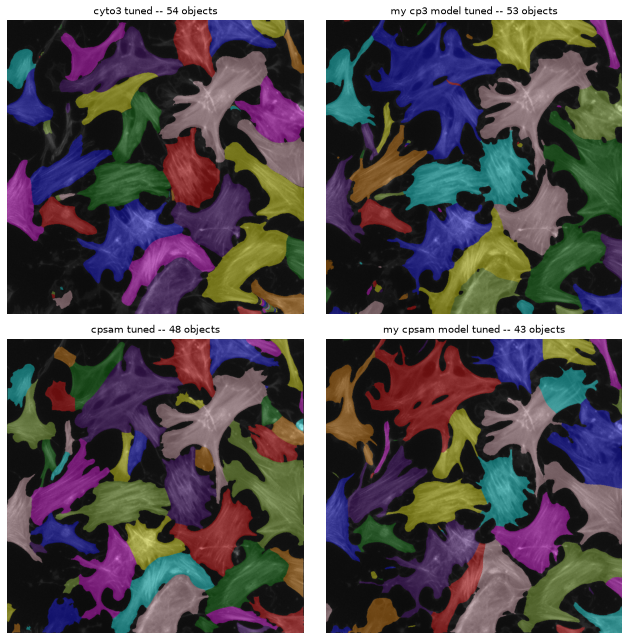

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(9, 9))
show(axes[0][0], labels_cyto3_tuned, "cyto3 tuned")
show(axes[0][1], labels_cp3_custom_tuned, "my cp3 model tuned")
show(axes[1][0], labels_cpsam_tuned, "cpsam tuned")
show(axes[1][1], labels_cpsam_custom_tuned, "my cpsam model tuned")
fig.tight_layout()

## Close the runner

Each environment that ran holds a worker process. Closing is not optional
housekeeping -- a kernel restarted without it leaves them running.

In [12]:
runner.close()